### Downloading the dataset
The dataset can be downloaded directly into your Google Colab environment using the [Kaggle API](https://www.kaggle.com/docs/api) as shown below. You can refer to this [post](https://medium.com/@opalkabert/downloading-kaggle-datasets-into-google-colab-fb9654c94235) on Medium for more details.

In [1]:
!pip install -U -q kaggle
!mkdir -p ~/.kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 19.2 MB/s eta 0:00:00


Upload Kaggle.json downloaded from your registered kaggle account

In [2]:
# from google.colab import files
# files.upload()

In [3]:
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d jessicali9530/celeba-dataset

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:20<00:00, 17.8MB/s]



In [4]:
import os
from glob import glob

WEIGHTS_FOLDER = './weights/'
DATA_FOLDER = './data/img_align_celeba/'

if not os.path.exists(WEIGHTS_FOLDER):
  os.makedirs(os.path.join(WEIGHTS_FOLDER,"AE"))
  os.makedirs(os.path.join(WEIGHTS_FOLDER,"VAE"))

# #Unzip the dataset downloaded from kaggle
from zipfile import ZipFile
with ZipFile('celeba-dataset.zip', 'r') as zipObj:
   # Extract all the contents of zip file in the data directory
   zipObj.extractall('./data/')

Caution (for Colab users) : Do not attempt to explore the directory using the viewer on the left as the page becomes unresponsive owing to the large size of the dataset.

### Imports

In [5]:
!pip install -q tf_keras

import numpy as np
import tf_keras as keras
import tf_keras.backend as K
from tf_keras.preprocessing.image import ImageDataGenerator
from tf_keras.layers import Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape, Lambda, Activation, BatchNormalization, LeakyReLU, Dropout
from tf_keras.models import Model
from tf_keras.optimizers import Adam
from tf_keras.callbacks import ModelCheckpoint
from keras import ops

### Data

In [6]:
import os
import numpy as np
from glob import glob

filenames = np.array(glob(os.path.join(DATA_FOLDER, '*/*.jpg')))
NUM_IMAGES = len(filenames)
print("Total number of images : " + str(NUM_IMAGES))

Total number of images : 202599


Since the dataset is quite large, we shall create an <i>ImageDataGenerator</i> object and employ its member function - <i>flow_from_directory</i> to define the flow of data directly from disk rather than loading the entire dataset into memory. The ImageDataGenerator can also be used to dynamically apply various transformations for image augmentation which is particularly useful in the case of small datasets.

I highly encourage you to refer to the [documentation](https://keras.io/preprocessing/image/#flow_from_directory) for understanding the various parameters of the dataflow function.

In [7]:
INPUT_DIM =  (128, 128, 3)
BATCH_SIZE = 512
Z_DIM =  200

data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(DATA_FOLDER,
                                                                   target_size = INPUT_DIM[:2],
                                                                   batch_size = BATCH_SIZE,
                                                                   shuffle = True,
                                                                   class_mode = 'input',
                                                                   subset = 'training'
                                                                   )

Found 202599 images belonging to 1 classes.


### MODEL ARCHITECTURE


#### Building the Encoder

In [8]:
# ENCODER
def build_encoder(input_dim, output_dim, conv_filters, conv_kernel_size,
                  conv_strides):

  # Clear tensorflow session to reset layer index numbers to 0 for LeakyRelu,
  # BatchNormalization and Dropout.
  # Otherwise, the names of above mentioned layers in the model
  # would be inconsistent
  global K
  K.clear_session()

  # Number of Conv layers
  n_layers = len(conv_filters)

  # Define model input
  encoder_input = Input(shape = input_dim, name = 'encoder_input')
  x = encoder_input

  # Add convolutional layers
  for i in range(n_layers):
        x = Conv2D(filters=conv_filters[i], kernel_size=conv_kernel_size[i], strides=conv_strides[i], padding='same', name=f'encoder_conv_{i}')(x)
        x = LeakyReLU()(x)
  # Required for reshaping latent vector while building Decoder
  shape_before_flattening = x.shape[1:]


  x = Flatten()(x)

  # Define model output
  encoder_output = Dense(output_dim, name='encoder_output')(x)

  return encoder_input, encoder_output, shape_before_flattening, Model(encoder_input, encoder_output)

<br><br>
The architecture of the Encoder, as shown below, consists of a stack of convolutional layers followed by a dense (fully connected) layer which outputs a vector of size 200.

In [9]:
encoder_input, encoder_output, shape_before_flattening, encoder = build_encoder(
    input_dim = INPUT_DIM,
    output_dim = Z_DIM,
    conv_filters = [32, 64, 64, 64],
    conv_kernel_size = [3,3,3,3],
    conv_strides = [2,2,2,2]
)


encoder.summary()
# use summary method to see the output of the encoder part

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 128, 128, 3)]     0         
                                                                 
 encoder_conv_0 (Conv2D)     (None, 64, 64, 32)        896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 32)        0         
                                                                 
 encoder_conv_1 (Conv2D)     (None, 32, 32, 64)        18496     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 32, 32, 64)        0         
                                                                 
 encoder_conv_2 (Conv2D)     (None, 16, 16, 64)        36928     
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 16, 16, 64)        0     

#### Building the Decoder


In [10]:
# Decoder
def build_decoder(input_dim, shape_before_flattening, conv_filters, conv_kernel_size,
                  conv_strides):

  # Number of Conv layers
  n_layers = len(conv_filters)

  # Define model input
  decoder_input = Input(shape = (input_dim,) , name = 'decoder_input')

  # To get an exact mirror image of the encoder
  x = Dense(int(np.prod(shape_before_flattening)))(decoder_input)
  x = Reshape(shape_before_flattening)(x)

  # Add convolutional layers
  for i in range(n_layers):
        x = Conv2DTranspose(filters=conv_filters[i], kernel_size=conv_kernel_size[i], strides=conv_strides[i], padding='same', name=f'decoder_conv_t_{i}')(x)

        if i < n_layers - 1:
            x = LeakyReLU()(x)
        else:
            x = Activation('sigmoid')(x)
  # Define model output
  decoder_output = x

  return decoder_input, decoder_output, Model(decoder_input, decoder_output)

<br><br>
Recall that it is the function of the Decoder to reconstruct the image from the latent vector. Therefore, it is necessary to define the decoder so as to increase the size of the activations gradually through the network. This can be achieved either through the [UpSampling2D](https://keras.io/layers/convolutional/#upsampling2d) layer or the [Conv2DTransponse](https://keras.io/layers/convolutional/#conv2dtranspose) layer.

Here, the Conv2DTranspose Layer is employed. This layer produces an output tensor double the size of the input tensor in both height and width.

<i>Note : The Decoder, in this example, is defined to be a mirror image of the encoder, which is not mandatory.</i>

<br><br>

In [11]:
decoder_input, decoder_output, decoder = build_decoder(input_dim = Z_DIM,
                                        shape_before_flattening = shape_before_flattening,
                                        conv_filters = [64,64,32,3],
                                        conv_kernel_size = [3,3,3,3],
                                        conv_strides = [2,2,2,2]
                                        )
# use summary method to see the model of decoder

#### Attaching the Decoder to the Encoder

In [12]:
simple_autoencoder_input = encoder_input
simple_autoencoder_output = decoder(encoder_output)

# Input to the combined model will be the input to the encoder.
# Output of the combined model will be the output of the decoder.
simple_autoencoder = Model(simple_autoencoder_input, simple_autoencoder_output)

simple_autoencoder.summary()
# use summary method to see the model of autoencoder

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 128, 128, 3)]     0         
                                                                 
 encoder_conv_0 (Conv2D)     (None, 64, 64, 32)        896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 32)        0         
                                                                 
 encoder_conv_1 (Conv2D)     (None, 32, 32, 64)        18496     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 32, 32, 64)        0         
                                                                 
 encoder_conv_2 (Conv2D)     (None, 16, 16, 64)        36928     
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 16, 16, 64)        0   

### COMPILATION AND TRAINING

The loss function used is a simple Root Mean Square Error (RMSE). The true output is the same batch of images that was fed to the model at its input layer. The Adam optimizer is optimizing the RMSE error for encoding the batch of images into their respective latent vectors and subsequently decoding them to reconstruct the images.

The ModelCheckpoint Keras callback saves the model weights for reuse. It overwrites the file with a fresh set of weights after every epoch.

NOTE : If you're using Google Colab, either download the weights to disc or mount your Google Drive.

In [13]:
LEARNING_RATE = 0.0005
N_EPOCHS = 10

optimizer = Adam(learning_rate = LEARNING_RATE)

def r_loss(y_true, y_pred):
    return K.mean(K.square(y_true - y_pred), axis=[1, 2, 3])

simple_autoencoder.compile(optimizer=optimizer, loss=r_loss)

checkpoint_ae = ModelCheckpoint(
    os.path.join(WEIGHTS_FOLDER, 'AE/autoencoder.weights.h5'),
    save_weights_only=True,
    verbose=1
)


<i>TIP</i> : Here's a really useful tip I found on Reddit (by arvind1096) - to prevent Google Colab from disconnecting due to a timeout issue, execute the following JS function in the Google Chrome console.

<br>
function ClickConnect(){console.log("Working");document.querySelector("colab-toolbar-button#connect").click()}setInterval(ClickConnect,60000)

In [14]:
simple_autoencoder.fit(
    data_flow,
    shuffle=True,
    epochs=N_EPOCHS,
    initial_epoch=0,
    steps_per_epoch=NUM_IMAGES // BATCH_SIZE,
    callbacks=[checkpoint_ae]
)


Epoch 1/10
395/395 [==============================] - ETA: 0s - loss: 0.0293
Epoch 1: saving model to ./weights/AE/autoencoder.weights.h5
395/395 [==============================] - 308s 747ms/step - loss: 0.0293
Epoch 2/10
395/395 [==============================] - ETA: 0s - loss: 0.0108
Epoch 2: saving model to ./weights/AE/autoencoder.weights.h5
395/395 [==============================] - 284s 718ms/step - loss: 0.0108
Epoch 3/10
395/395 [==============================] - ETA: 0s - loss: 0.0091
Epoch 3: saving model to ./weights/AE/autoencoder.weights.h5
395/395 [==============================] - 282s 713ms/step - loss: 0.0091
Epoch 4/10
395/395 [==============================] - ETA: 0s - loss: 0.0083
Epoch 4: saving model to ./weights/AE/autoencoder.weights.h5
395/395 [==============================] - 280s 709ms/step - loss: 0.0083
Epoch 5/10
395/395 [==============================] - ETA: 0s - loss: 0.0079
Epoch 5: saving model to ./weights/AE/autoencoder.weights.h5
395/395 [=====

### RECONSTRUCTION

The first step is to generate a new batch of images using the ImageDataGenerator defined in the 'Data' section at the top. The images are returned as an array and the number of images is equal to BATCH_SIZE.

In [15]:
example_batch = next(data_flow)
example_batch = example_batch[0]
example_images = example_batch[:10]

In [16]:
example_images.shape

(10, 128, 128, 3)

#### Displaying the reconstructed images

In [17]:
import matplotlib.pyplot as plt

In [18]:
def plot_compare(images=None, add_noise=False):

  if images is None:
    example_batch = next(data_flow)
    example_batch = example_batch[0]
    images = example_batch[:10]

  n_to_show = images.shape[0]

  if add_noise:
    encodings = encoder.predict(images) # use the prediction function of encoder
    encodings += np.random.normal(0.0, 1.0, size = (n_to_show,200))
    reconst_images = decoder.predict(encodings) # use the prediction of decoder

  else:
    reconst_images = simple_autoencoder.predict(images)# complete with autoencoder function you had

  fig = plt.figure(figsize=(15, 3))
  fig.subplots_adjust(hspace=0.4, wspace=0.4)

  for i in range(n_to_show):
      img = images[i].squeeze()
      sub = fig.add_subplot(2, n_to_show, i+1)
      sub.axis('off')
      sub.imshow(img)

  for i in range(n_to_show):
      img = img = reconst_images[i].squeeze() # use the reconstruction function here
      sub = fig.add_subplot(2, n_to_show, i+n_to_show+1)
      sub.axis('off')
      sub.imshow(img)

1/1 [==============================] - 0s 365ms/step


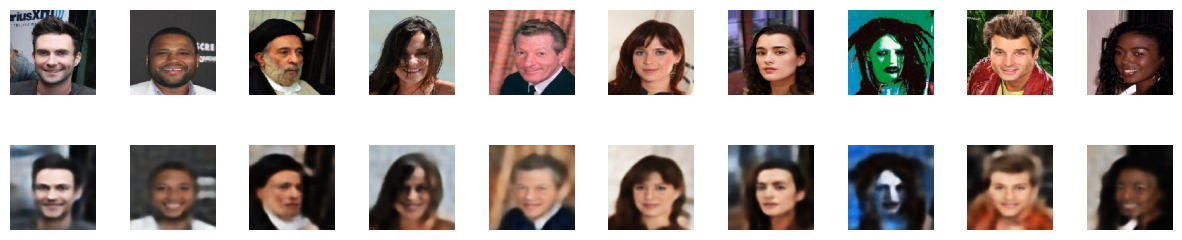

In [19]:
plot_compare(example_images)

The first row shows images directly from the dataset and the second row shows images that have been passed through the Autoencoder. Evidently, the model has learned to encode and decode (reconstruct) fairly well.

NOTE : A reason why the images lack sharpness is due to the RMSE loss as it averages out the differences between individual pixel values. Generative Adversarial Networks on the contrary, produce much sharper images.

## VARIATIONAL AUTOENCODER



#### Building the Encoder


In [20]:
import tensorflow as tf

# ENCODER
def build_vae_encoder(input_dim, output_dim, conv_filters, conv_kernel_size,
                  conv_strides, use_batch_norm = False, use_dropout = False):

  # Clear tensorflow session to reset layer index numbers to 0 for LeakyRelu,
  # BatchNormalization and Dropout.
  # Otherwise, the names of above mentioned layers in the model
  # would be inconsistent
  global K
  K.clear_session()

  # Number of Conv layers
  n_layers = len(conv_filters)

  # Define model input
  encoder_input = Input(shape = input_dim, name = 'encoder_input')
  x = encoder_input

  # Add convolutional layers
  for i in range(n_layers):
      x = Conv2D(filters=conv_filters[i], kernel_size=conv_kernel_size[i], strides=conv_strides[i], padding='same', name=f'encoder_conv_{i}')(x)# use conv2d function here
      if use_batch_norm:
        x = BatchNormalization()(x)# use batch normalization here

      x = LeakyReLU()(x)# use leakyrelu function here

      if use_dropout:
        x = Dropout(0.25)(x)# use dropout with rate = 0.25 here

  # Required for reshaping latent vector while building Decoder
  shape_before_flattening = tuple(x.shape[1:])

  x = Flatten()(x)# flatten the output

  mean_mu = Dense(output_dim, name = 'mu')(x)
  log_var = Dense(output_dim, name = 'log_var')(x)

  # Defining a function for sampling
  def sampling(args):
    mean_mu, log_var = args
    epsilon = tf.random.normal(shape=tf.shape(mean_mu))
    return mean_mu + K.exp(0.5 * log_var) * epsilon

  # Using a Keras Lambda Layer to include the sampling function as a layer
  # in the model
  encoder_output = Lambda(
    sampling,
    output_shape=(output_dim,),
    name='encoder_output'
)([mean_mu, log_var])

  return encoder_input, encoder_output, mean_mu, log_var, shape_before_flattening, Model(encoder_input, encoder_output)

In [21]:
vae_encoder_input, vae_encoder_output, mean_mu, log_var, vae_shape_before_flattening, vae_encoder = build_vae_encoder(
    input_dim=INPUT_DIM, output_dim=Z_DIM,
    conv_filters=[32, 64, 64, 64], conv_kernel_size=[3,3,3,3], conv_strides=[2,2,2,2],
    use_batch_norm=True, use_dropout=True
)
vae_encoder.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 encoder_conv_0 (Conv2D)     (None, 64, 64, 32)           896       ['encoder_input[0][0]']       
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 32)           128       ['encoder_conv_0[0][0]']      
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 32)           0         ['batch_normalization[0][0

#### Building the Decoder
Since the Decoder remains the same, the Decoder architecture of the Simple Autoencoder is reused.

In [22]:
vae_decoder_input, vae_decoder_output, vae_decoder = build_decoder(
    input_dim=Z_DIM, shape_before_flattening=vae_shape_before_flattening,
    conv_filters=[64,64,32,3], conv_kernel_size=[3,3,3,3], conv_strides=[2,2,2,2]
)
vae_decoder.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 decoder_input (InputLayer)  [(None, 200)]             0         
                                                                 
 dense (Dense)               (None, 4096)              823296    
                                                                 
 reshape (Reshape)           (None, 8, 8, 64)          0         
                                                                 
 decoder_conv_t_0 (Conv2DTr  (None, 16, 16, 64)        36928     
 anspose)                                                        
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 16, 16, 64)        0         
                                                                 
 decoder_conv_t_1 (Conv2DTr  (None, 32, 32, 64)        36928     
 anspose)                                                  

#### Attaching the Decoder to the Encoder


In [23]:
#######################################################################
###### in this part you should attach and build the VAE together ######
#######################################################################
vae_input = vae_encoder_input

vae_output = vae_decoder(vae_encoder_output)

vae_model = Model(vae_input, vae_output)


### COMPILATION AND TRAINING


The loss function is a sum of RMSE and KL Divergence. A weight is assigned to the RMSE loss, known as the loss factor. The loss factor is multiplied with the RMSE loss. If we use a high loss factor, the drawbacks of a Simple Autoencoder start to appear. However, if we use a loss factor too low, the quality of the reconstructed images will be poor. Hence the loss factor is a hyperparameter that needs to be tuned.

In [24]:
LEARNING_RATE = 0.0005
N_EPOCHS = 10
LOSS_FACTOR = 10000

In [25]:
kl_loss = -0.5 * K.sum(1 + log_var - K.square(mean_mu) - K.exp(log_var), axis=1)
vae_model.add_loss(K.mean(kl_loss))

def r_loss(y_true, y_pred):
    return K.mean(K.square(y_true - y_pred), axis=[1, 2, 3])

def reconstruction_loss(y_true, y_pred):
    return LOSS_FACTOR * r_loss(y_true, y_pred)

In [26]:
adam_optimizer = Adam(learning_rate=LEARNING_RATE)
vae_model.compile(optimizer=adam_optimizer, loss=reconstruction_loss)

checkpoint_vae = ModelCheckpoint(
    os.path.join(WEIGHTS_FOLDER, 'VAE/vae.weights.h5'),
    save_weights_only=True,
    verbose=1
)

In [27]:
vae_model.fit(
    data_flow,
    shuffle=True,
    epochs=N_EPOCHS,
    initial_epoch=0,
    steps_per_epoch=NUM_IMAGES // BATCH_SIZE,
    callbacks=[checkpoint_vae]
)

Epoch 1/10
395/395 [==============================] - ETA: 0s - loss: 423.5204
Epoch 1: saving model to ./weights/VAE/vae.weights.h5
395/395 [==============================] - 293s 724ms/step - loss: 423.5204
Epoch 2/10
395/395 [==============================] - ETA: 0s - loss: 267.1437
Epoch 2: saving model to ./weights/VAE/vae.weights.h5
395/395 [==============================] - 291s 737ms/step - loss: 267.1437
Epoch 3/10
395/395 [==============================] - ETA: 0s - loss: 241.0838
Epoch 3: saving model to ./weights/VAE/vae.weights.h5
395/395 [==============================] - 293s 742ms/step - loss: 241.0838
Epoch 4/10
395/395 [==============================] - ETA: 0s - loss: 231.4732
Epoch 4: saving model to ./weights/VAE/vae.weights.h5
395/395 [==============================] - 288s 729ms/step - loss: 231.4732
Epoch 5/10
395/395 [==============================] - ETA: 0s - loss: 226.2955
Epoch 5: saving model to ./weights/VAE/vae.weights.h5
395/395 [======================

### RECONSTRUCTION.
The reconstruction process is the same as that of the Simple Autoencoder.

In [28]:
example_batch = next(data_flow)
example_batch = example_batch[0]
example_images = example_batch[:10]

In [29]:
def plot_compare_vae(images=None):

  if images is None:
    example_batch = next(data_flow)
    example_batch = example_batch[0]
    images = example_batch[:10]

  n_to_show = images.shape[0]
  reconst_images = vae_model.predict(images)

  fig = plt.figure(figsize=(15, 3))
  fig.subplots_adjust(hspace=0.4, wspace=0.4)

  for i in range(n_to_show):
      img = images[i].squeeze()
      sub = fig.add_subplot(2, n_to_show, i+1)
      sub.axis('off')
      sub.imshow(img)

  for i in range(n_to_show):
      img = reconst_images[i].squeeze()
      sub = fig.add_subplot(2, n_to_show, i+n_to_show+1)
      sub.axis('off')
      sub.imshow(img)

1/1 [==============================] - 0s 202ms/step


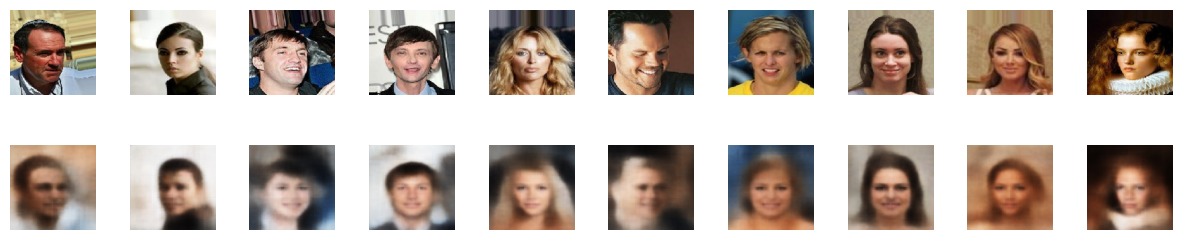

In [30]:
plot_compare_vae(images = example_images)

### Generating new faces from random vectors sampled from a standard normal distribution.

In [31]:
def vae_generate_images(n_to_show=10):
  reconst_images = vae_decoder.predict(np.random.normal(0,1,size=(n_to_show,Z_DIM)))

  fig = plt.figure(figsize=(15, 3))
  fig.subplots_adjust(hspace=0.4, wspace=0.4)

  for i in range(n_to_show):
        img = reconst_images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+1)
        sub.axis('off')
        sub.imshow(img)

1/1 [==============================] - 0s 99ms/step


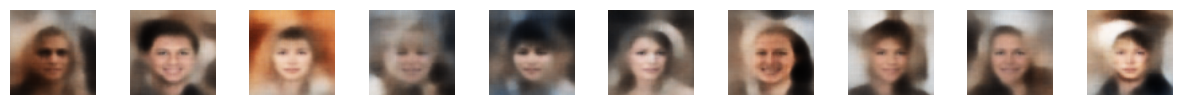

In [32]:
vae_generate_images(n_to_show=10)